<a href="https://colab.research.google.com/github/Hudhaifa-22/ICT-project/blob/main/ML_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install if needed
!pip install scikit-learn pandas numpy

# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import pandas as pd

df = pd.read_csv("Emotion_classify_Data.csv.xls")

df.head()

,Comment,Emotion
0,i seriously hate one subject to death but now ...,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feel...,fear
3,ive been really angry with r and i feel like a...,joy
4,i feel suspicious if there is no one outside l...,fear


In [ ]:
df.columns

Index(['Comment', 'Emotion'], dtype='object')

In [ ]:
df.isnull().sum()

NameError: name 'df' is not defined

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.rename(columns={
    "Comment": "text",
    "Emotion": "emotion"
})

df.head()

,text,emotion
0,i seriously hate one subject to death but now ...,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feel...,fear
3,ive been really angry with r and i feel like a...,joy
4,i feel suspicious if there is no one outside l...,fear


In [ ]:
df.describe()

,text,emotion
count,5937,5937
unique,5934,3
top,i feel pretty tortured because i work a job an...,anger
freq,2,2000


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

#vectorizer = TfidfVectorizer()

#X = vectorizer.fit_transform(df['text'])
#y = df['emotion']

In [ ]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 53240 stored elements and shape (5937, 5000)>

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of y_train: ", y_train.shape)
print("Shape of y_test: ", y_test.shape)

Shape of X_train:  (4749, 5000)
Shape of X_test:  (1188, 5000)
Shape of y_train:  (4749,)
Shape of y_test:  (1188,)


In [ ]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)

X = vectorizer.fit_transform(df['text'])

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['emotion'] = le.fit_transform(df['emotion'])

(samples,features)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_predlr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_predlr))
print(classification_report(y_test, y_predlr))

Accuracy: 0.9587542087542088
              precision    recall  f1-score   support

       anger       0.94      0.96      0.95       392
        fear       0.98      0.94      0.96       416
         joy       0.96      0.98      0.97       380

    accuracy                           0.96      1188
   macro avg       0.96      0.96      0.96      1188
weighted avg       0.96      0.96      0.96      1188



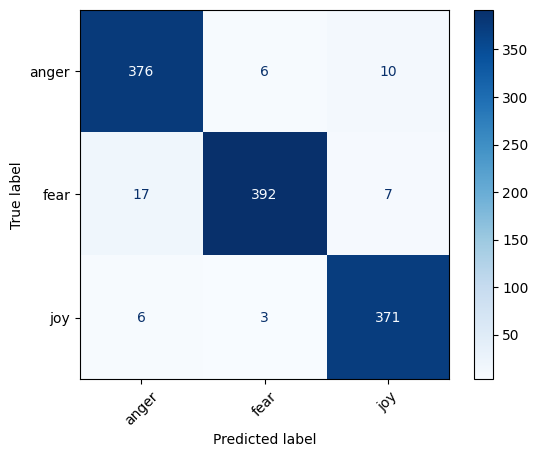

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_predlr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr.classes_)
disp.plot(cmap="Blues")
plt.xticks(rotation=45)
plt.show()

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_prednb = nb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_prednb))
print(classification_report(y_test, y_prednb))

Accuracy: 0.9292929292929293
              precision    recall  f1-score   support

       anger       0.91      0.94      0.92       392
        fear       0.94      0.92      0.93       416
         joy       0.94      0.93      0.94       380

    accuracy                           0.93      1188
   macro avg       0.93      0.93      0.93      1188
weighted avg       0.93      0.93      0.93      1188



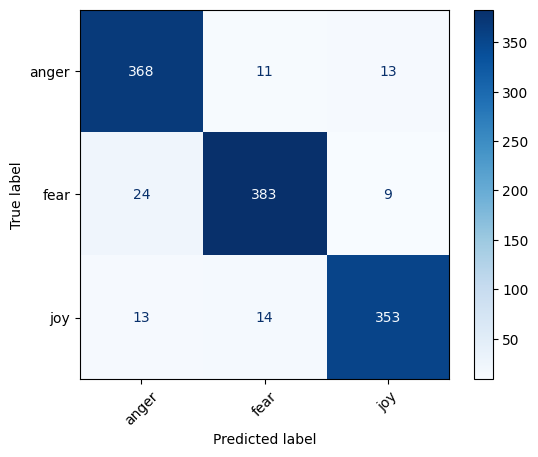

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_prednb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb.classes_)
disp.plot(cmap="Blues")
plt.xticks(rotation=45)
plt.show()

In [ ]:
from  sklearn.svm import SVC

svc = SVC()
svc.fit(X_train, y_train)

SVC()

In [ ]:
y_predsvc = svc.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_predsvc))
print(classification_report(y_test, y_predsvc))

Accuracy: 0.9486531986531986
              precision    recall  f1-score   support

       anger       0.93      0.96      0.94       392
        fear       0.98      0.91      0.95       416
         joy       0.94      0.98      0.96       380

    accuracy                           0.95      1188
   macro avg       0.95      0.95      0.95      1188
weighted avg       0.95      0.95      0.95      1188



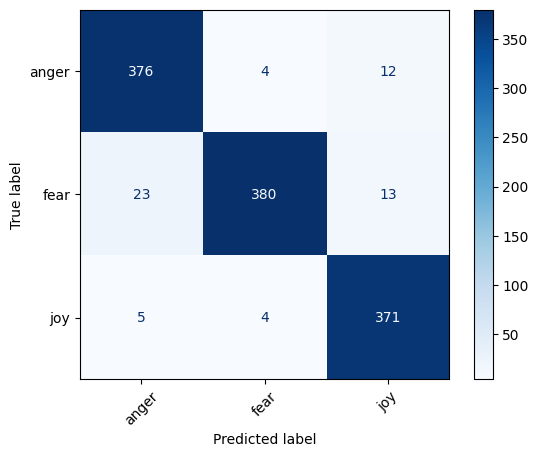

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_predsvc)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svc.classes_)
disp.plot(cmap="Blues")
plt.xticks(rotation=45)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_predrf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_predrf))
print(classification_report(y_test, y_predrf))

Accuracy: 0.9486531986531986
              precision    recall  f1-score   support

       anger       0.92      0.95      0.93       392
        fear       0.97      0.93      0.95       416
         joy       0.96      0.97      0.96       380

    accuracy                           0.95      1188
   macro avg       0.95      0.95      0.95      1188
weighted avg       0.95      0.95      0.95      1188



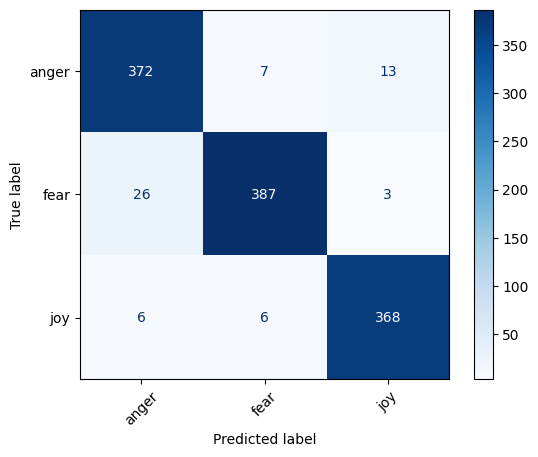

In [ ]:
cm = confusion_matrix(y_test, y_predrf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap="Blues")
plt.xticks(rotation=45)
plt.show()

compare accuracy

In [ ]:
print("Accuracy of logistic regression:", accuracy_score(y_test, y_predlr))
print("Accuracy naive bayers:", accuracy_score(y_test, y_prednb))
print("Accuracy of svc:", accuracy_score(y_test, y_predsvc))
print("Accuracy of random forest:", accuracy_score(y_test, y_predrf))

Accuracy of logistic regression: 0.9587542087542088
Accuracy naive bayers: 0.9292929292929293
Accuracy of svc: 0.9486531986531986
Accuracy of random forest: 0.9486531986531986


processing code

In [ ]:
def predict_emotion(text):
    text_vector = vectorizer.transform([text])
    prediction = lr.predict(text_vector)[0]
    return prediction

In [ ]:
def give_suggestion(emotion):
    if emotion.lower() == "happy":
        return "Keep spreading positivity!"
    elif emotion.lower() == "sad":
        return "Talk to someone you trust and take rest."
    elif emotion.lower() == "anger":
        return "Take deep breaths and calm your mind."
    elif emotion.lower() == "fear":
        return "Stay strong. Focus on solutions."
    elif emotion.lower() == "love":
        return "Share your happiness with others!"
    else:
        return "Take care of yourself."

In [ ]:
user_input = input("How are you feeling today? ")

emotion = predict_emotion(user_input)
suggestion = give_suggestion(emotion)

print("Detected Emotion:", emotion)
print("Suggestion:", suggestion)

How are you feeling today? i am feeling good
Detected Emotion: joy
Suggestion: Take care of yourself.


In [ ]:
import pickle

pickle.dump(model, open("emotion_model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [ ]:
from google.colab import files
files.download("emotion_model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def give_suggestion1(emotion):
    suggestions = {
        "happy": "Keep spreading positivity and gratitude.",
        "sad": "Take a short walk or talk to someone you trust.",
        "anger": "Pause, breathe deeply, and reflect calmly.",
        "fear": "Focus on what you can control and stay confident.",
        "love": "Express your appreciation to someone special."
    }

    return suggestions.get(emotion.lower(), "Take care of your mental well-being.")

In [ ]:
def predict_emotion1(text):
    text_vector = vectorizer.transform([text])
    prediction = [lr.predict(text_vector)[0], nb.predict(text_vector)[0], svc.predict(text_vector)[0], rf.predict(text_vector)[0]]
    return prediction

In [ ]:
while True:
    user_input = input("Enter how you feel (type 'exit' to stop): ")

    if user_input.lower() == "exit":
        break

    emotion = predict_emotion1(user_input)
    #suggestion = give_suggestion1(emotion)
    cla = ["Logistic Regression", "Naive Bayes", "Support Vector Machine","random forest"]
    j=0
    for emo in emotion:
        if emo == "random forest":
          emo = le.inverse_transform([emo])[0]
        print("Classifier used:-",cla[j])
        print("Detected Emotion:", emo)
        print("Suggestion:", give_suggestion1(emo))
        j+=1
    print("-" * 40)

Enter how you feel (type 'exit' to stop): nothing
Classifier used:- Logistic Regression
Detected Emotion: joy
Suggestion: Take care of your mental well-being.
Classifier used:- Naive Bayes
Detected Emotion: joy
Suggestion: Take care of your mental well-being.
Classifier used:- Support Vector Machine
Detected Emotion: anger
Suggestion: Pause, breathe deeply, and reflect calmly.
Classifier used:- random forest
Detected Emotion: anger
Suggestion: Pause, breathe deeply, and reflect calmly.
----------------------------------------


KeyboardInterrupt: Interrupted by user